# Method 1 - Two separate models

In [ ]:
from __future__ import print_function

import pretty_midi
import numpy as np
import matplotlib.pyplot as plt

import collections
import pathlib
import pandas as pd

from IPython import display
from typing import Optional

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn

In [6]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Tempo, Key or Time signature change events found"
)

### Open data

In [7]:
data_dir = pathlib.Path("../data")
filenames = list(data_dir.rglob("*.mid")) + list(data_dir.rglob("*.midi"))

print("Number of files:", len(filenames))

Number of files: 778


### Display audio 

In [8]:
def display_audio(pm: pretty_midi.PrettyMIDI, seconds=300):
  _SAMPLING_RATE=16000
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  return display.Audio(waveform_short, rate=_SAMPLING_RATE)

### Convert from Midi to tabke with notes

In [9]:
def midi_to_notes(instrument: pretty_midi.Instrument) -> pd.DataFrame:
  notes = collections.defaultdict(list)

  # Sort the notes by start time, chronological order
  sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
  prev_start = sorted_notes[0].start

  for note in sorted_notes:
    start = note.start
    end = note.end
    notes['pitch'].append(note.pitch)
    notes['start'].append(start)
    notes['end'].append(end)
    notes['global_start'].append(start)
    notes['step'].append(start - prev_start)
    notes['duration'].append(end - start)
    prev_start = start

  return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

### Piano roll

In [10]:
def plot_piano_roll(notes: pd.DataFrame, count: Optional[int] = None):
  if count:
    title = f'First {count} notes'
  else:
    title = f'Whole track'
    count = len(notes['pitch'])
  plt.figure(figsize=(12, 4))
  plot_pitch = np.stack([notes['pitch'], notes['pitch']], axis=0)
  plot_start_stop = np.stack([notes['start'], notes['end']], axis=0)
  plt.plot(
      plot_start_stop[:, :count], plot_pitch[:, :count], color="b", marker=".")
  plt.xlabel('Time [s]', size = 14)
  plt.ylabel('Pitch', size=14)
  _ = plt.title(title, size=14)

Instrument(program=26, is_drum=False, name="Guitar")


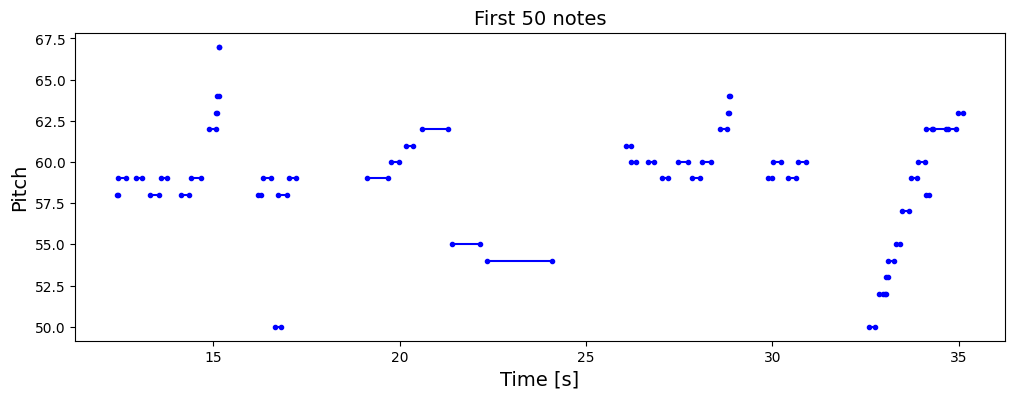

In [11]:
sample_file=filenames[4]
pm = pretty_midi.PrettyMIDI(sample_file)
print(pm.instruments[0])
instrument = pm.instruments[0]

plot_piano_roll(midi_to_notes(instrument), count=50)

### Convert from table with notes back to Midi

In [12]:
def notes_to_midi(notes: pd.DataFrame, program_name: int, is_drum: bool, velocity: int = 100, 
) -> pretty_midi.PrettyMIDI:

  pm = pretty_midi.PrettyMIDI()
  instrument = pretty_midi.Instrument(
      program=program_name, is_drum=is_drum)

  prev_start = 0
  for i, note in notes.iterrows():
    start = float(prev_start + note['step'])
    end = float(start + note['duration'])
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=int(note['pitch']),
        start = float(prev_start + note['step']),
        end = float(start + note['duration'])
    )
    instrument.notes.append(note)
    prev_start = start

  pm.instruments.append(instrument)
  
  return pm

### Train test split

In [13]:
from sklearn.model_selection import train_test_split
train_files, test_files = train_test_split(filenames, test_size=0.2, random_state=42, shuffle=True)

In [14]:
print("Number of files:", len(train_files))

Number of files: 622


### Collect all drum and piano notes from the music

In [15]:
drum_data = []
piano_data = []
for f in train_files:
  try:
    pm_f = pretty_midi.PrettyMIDI(f)
    for i, inst in enumerate(pm_f.instruments):
      if inst.is_drum == True:
          drum_notes = midi_to_notes(inst) # dataframe 
          drum_data.append(drum_notes) # lista med df
      else:
        if 31< inst.program <40:
          bass_notes = midi_to_notes(inst)
          drum_data.append(bass_notes)
        elif inst.program <31:
          piano_notes = midi_to_notes(inst)
          piano_data.append(piano_notes)
  except:
    print(f"Error processing file: {f}")
drum_data = pd.concat(drum_data) # one dataframe
piano_data = pd.concat(piano_data) 

Error processing file: ../data/JAZZ MIDIS ABC/K-M/maiden_voyage-HHancock_bg.mid
Error processing file: ../data/JAZZ MIDIS ABC/ABC/a_taste_of_honey_jc2.mid
Error processing file: ../data/JAZZ MIDIS ABC/N-R/on_the_sunny_side_of_the_street_rw.mid


In [16]:
drum_data.head()

,pitch,start,end,global_start,step,duration
0,36,3.531246,3.533084,3.531246,0.000000,0.001838
1,42,3.531246,3.533084,3.531246,0.000000,0.001838
2,42,3.972422,3.974260,3.972422,0.441176,0.001838
3,37,4.413598,4.415436,4.413598,0.441176,0.001838
4,42,4.413598,4.415436,4.413598,0.000000,0.001838


### Sequence data

In [17]:
key_order = ['pitch', 'step', 'duration']
piano_train_notes = np.stack([piano_data[key] for key in key_order], axis=1)
drum_train_notes = np.stack([drum_data[key] for key in key_order], axis=1)

In [18]:
class SequenceDataset(Dataset):
    def __init__(self, notes, seq_length, vocab_size=128):
        """
        notes: Tensor [N, 3] -> pitch, step, duration
        """
        self.notes = notes
        self.seq_length = seq_length
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.notes) - self.seq_length # how many windows can be made

    def __getitem__(self, idx):
        seq = self.notes[idx:idx + self.seq_length + 1]

        inputs = seq[:-1] # all notes in window except last one
        target = seq[-1] # last one

        # Normalize
        inputs = inputs.clone()
        inputs[:, 0] /= self.vocab_size # values between 0 and 1

        labels = {
            "pitch": target[0].long(),   # classification
            "step": target[1],           # regression
            "duration": target[2],       # regression
        }

        return inputs, labels

In [19]:
seq_length = 50
piano_train_notes = torch.tensor(piano_train_notes, dtype=torch.float32)
piano_dataset = SequenceDataset(piano_train_notes, seq_length)
piano_loader = DataLoader(piano_dataset, batch_size=128, shuffle=True)

drum_train_notes = torch.tensor(drum_train_notes, dtype=torch.float32)
drum_dataset = SequenceDataset(drum_train_notes, seq_length)
drum_loader = DataLoader(drum_dataset, batch_size=128, shuffle=True)

### Create the model

In [20]:
class MusicLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, pitch_classes=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.pitch_head = nn.Linear(hidden_size, pitch_classes)
        self.step_head = nn.Linear(hidden_size, 1)
        self.duration_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x) #(output, (h_n, c_n))
        h = h_n[-1]
        
        return {
            "pitch": self.pitch_head(h),
            "step": self.step_head(h).squeeze(-1),
            "duration": self.duration_head(h).squeeze(-1),
        }

In [21]:
def mae(y_pred, y_true):
    return torch.mean(torch.abs(y_true - y_pred))

### Device for gpu

In [22]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


### Drum model

In [23]:
drum_model = MusicLSTM().to(device)
optimizer = torch.optim.Adam(drum_model.parameters(), lr=0.001)

pitch_loss_fn = nn.CrossEntropyLoss()

In [24]:
epochs=25
loss_list_drum=[]
for epoch in range(epochs):
    total_loss = 0.0

    for x, y in drum_loader:
        x = x.to(device)

        y["pitch"] = y["pitch"].to(device)
        y["step"] = y["step"].to(device)
        y["duration"] = y["duration"].to(device)
        
        optimizer.zero_grad()

        outputs = drum_model(x)

        loss_pitch = pitch_loss_fn(outputs["pitch"], y["pitch"])
        loss_step = mae(outputs["step"], y["step"])
        loss_duration = mae(outputs["duration"], y["duration"])

        loss = loss_pitch + 1.5*loss_step + loss_duration
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    loss_list_drum.append(total_loss)
    print(f"Epoch {epoch+1}, loss: {total_loss:.4f}")

Epoch 1, loss: 29513.7798
Epoch 2, loss: 25208.5028
Epoch 3, loss: 23008.6959
Epoch 4, loss: 21575.9188
Epoch 5, loss: 20508.7333
Epoch 6, loss: 19678.5433
Epoch 7, loss: 19014.2768
Epoch 8, loss: 18521.4010
Epoch 9, loss: 18094.8076
Epoch 10, loss: 17801.0049
Epoch 11, loss: 17476.8831
Epoch 12, loss: 17206.5941
Epoch 13, loss: 16998.1481
Epoch 14, loss: 16829.8081
Epoch 15, loss: 16649.1024
Epoch 16, loss: 16512.7902
Epoch 17, loss: 16373.6617
Epoch 18, loss: 16257.9775
Epoch 19, loss: 16160.4636
Epoch 20, loss: 16073.0729
Epoch 21, loss: 16019.2437
Epoch 22, loss: 15934.2223
Epoch 23, loss: 15847.1195
Epoch 24, loss: 15774.6869
Epoch 25, loss: 15737.4998


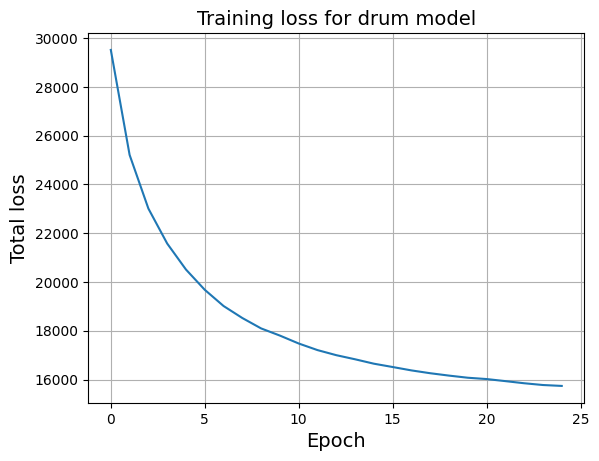

In [25]:
import matplotlib.pyplot as plt
plt.plot(loss_list_drum)
plt.xlabel("Epoch", size =14)
plt.ylabel("Total loss", size=14)
plt.title("Training loss for drum model", size=14)
plt.grid(True)

### Piano model

In [26]:
piano_model = MusicLSTM().to(device)
optimizer = torch.optim.Adam(piano_model.parameters(), lr=0.001)

pitch_loss_fn = nn.CrossEntropyLoss()

In [27]:
epochs=25
loss_list_piano=[]
for epoch in range(epochs):
    total_loss = 0.0

    for x, y in piano_loader:
        x = x.to(device)

        y["pitch"] = y["pitch"].to(device)
        y["step"] = y["step"].to(device)
        y["duration"] = y["duration"].to(device)

        optimizer.zero_grad()

        outputs = piano_model(x)

        loss_pitch = pitch_loss_fn(outputs["pitch"], y["pitch"])
        loss_step = mae(outputs["step"], y["step"])
        loss_duration = mae(outputs["duration"], y["duration"])

        loss = 1.5*loss_pitch + loss_step + loss_duration
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    loss_list_piano.append(total_loss)
    print(f"Epoch {epoch+1}, loss: {total_loss:.4f}")

Epoch 1, loss: 54037.2782
Epoch 2, loss: 50091.2281
Epoch 3, loss: 48360.7120
Epoch 4, loss: 47159.2512
Epoch 5, loss: 46300.0872
Epoch 6, loss: 45692.1263
Epoch 7, loss: 45167.2865
Epoch 8, loss: 44742.6709
Epoch 9, loss: 44383.5877
Epoch 10, loss: 44094.3981
Epoch 11, loss: 43825.0855
Epoch 12, loss: 43699.7140
Epoch 13, loss: 43442.5550
Epoch 14, loss: 43254.9042
Epoch 15, loss: 43098.9228
Epoch 16, loss: 42921.7777
Epoch 17, loss: 42783.3650
Epoch 18, loss: 42665.1499
Epoch 19, loss: 42594.1787
Epoch 20, loss: 42460.3020
Epoch 21, loss: 42378.5474
Epoch 22, loss: 42370.3544
Epoch 23, loss: 42178.4419
Epoch 24, loss: 42146.1888
Epoch 25, loss: 42120.8009


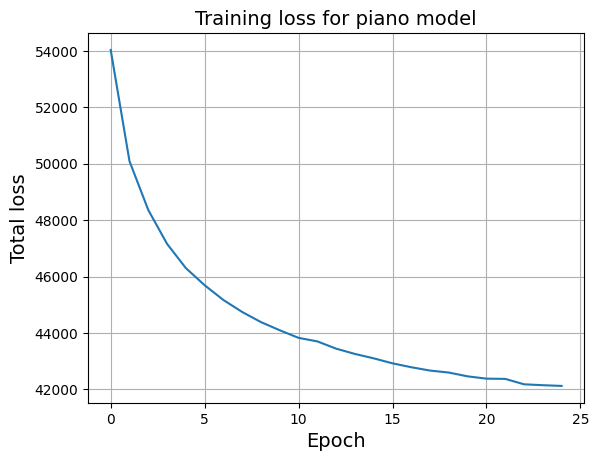

In [28]:
plt.plot(loss_list_piano)
plt.xlabel("Epoch", size=14)
plt.ylabel("Total loss", size=14)
plt.title("Training loss for piano model", size=14)
plt.grid(True)

### Adding randomness to the pitch

In [29]:
def sample_pitch(logits, temperature=0.5):
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

### Prediction - generating notes

In [30]:
def generate_notes(model, seed, num_notes=200, temperature=0.5, vocab_size=128):
    model.eval()

    generated = []
    current_seq = seed.clone()

    for _ in range(num_notes):
        with torch.no_grad():
            out = model(current_seq.unsqueeze(0))

        pitch = sample_pitch(out["pitch"][0], temperature) #[0] since batches
        step = torch.relu(out["step"][0]).item()
        duration = torch.relu(out["duration"][0]).item()

        generated.append([
            pitch,
            step,
            duration,
        ])

        new_note = torch.tensor([pitch / vocab_size, step, duration], dtype=torch.float32, device=current_seq.device)
        current_seq = torch.cat([current_seq[1:], new_note.unsqueeze(0)], dim=0)

    return generated

In [31]:
def generate_based_on_model(model, pm):
        pm_out = pretty_midi.PrettyMIDI()
        raw_notes = midi_to_notes(pm)
        seed = torch.tensor(
        raw_notes[["pitch", "step", "duration"]].values, dtype=torch.float32, device=device)
        
        seed_s = seed[0:seq_length]
        gen=generate_notes(model, seed_s, num_notes=100)

        generated_df = pd.DataFrame(gen, columns=["pitch", "step", "duration"])

        midifile=notes_to_midi(generated_df, pm.program, pm.is_drum)
        print(midifile.instruments)
        pm_out.instruments.append(midifile.instruments[0])
        return pm_out


### Use an out of sample song as the seed to generate music

In [42]:
sample_file='../FreckleFace.MID'

In [55]:
pm = pretty_midi.PrettyMIDI(sample_file)
pm.instruments

[Instrument(program=32, is_drum=True, name=""),
 Instrument(program=32, is_drum=False, name=""),
 Instrument(program=0, is_drum=False, name=""),
 Instrument(program=65, is_drum=False, name=""),
 Instrument(program=72, is_drum=False, name=""),
 Instrument(program=65, is_drum=False, name=""),
 Instrument(program=66, is_drum=False, name=""),
 Instrument(program=66, is_drum=False, name=""),
 Instrument(program=67, is_drum=False, name=""),
 Instrument(program=58, is_drum=False, name=""),
 Instrument(program=59, is_drum=False, name=""),
 Instrument(program=56, is_drum=False, name=""),
 Instrument(program=58, is_drum=False, name=""),
 Instrument(program=56, is_drum=False, name=""),
 Instrument(program=59, is_drum=False, name=""),
 Instrument(program=58, is_drum=False, name=""),
 Instrument(program=56, is_drum=False, name=""),
 Instrument(program=59, is_drum=False, name=""),
 Instrument(program=58, is_drum=False, name=""),
 Instrument(program=56, is_drum=False, name=""),
 Instrument(program=59

In [44]:
pm = pretty_midi.PrettyMIDI(sample_file)
drum_pm = pretty_midi.PrettyMIDI()
piano_pm = pretty_midi.PrettyMIDI()

for inst in pm.instruments:
    if inst.is_drum:
        drum_pm.instruments.append(inst)
    else:
        if inst.program == 0:
            piano_pm.instruments.append(inst)

predict drums notes

In [45]:
seed = drum_pm.instruments[0]
pm_out_drums=generate_based_on_model(drum_model, seed)

[Instrument(program=32, is_drum=True, name="")]


predict piano notes

In [46]:
pm_out_piano=generate_based_on_model(piano_model, piano_pm.instruments[0])

[Instrument(program=0, is_drum=False, name="")]


Combine the generated drums and piano

In [47]:
pm_together = pretty_midi.PrettyMIDI()
pm_together.instruments.append(pm_out_drums.instruments[0])
pm_together.instruments.append(pm_out_piano.instruments[0])

In [48]:
pm_together.instruments

[Instrument(program=32, is_drum=True, name=""),
 Instrument(program=0, is_drum=False, name="")]

In [49]:
pm_together.write("method1_generated_music05.mid")

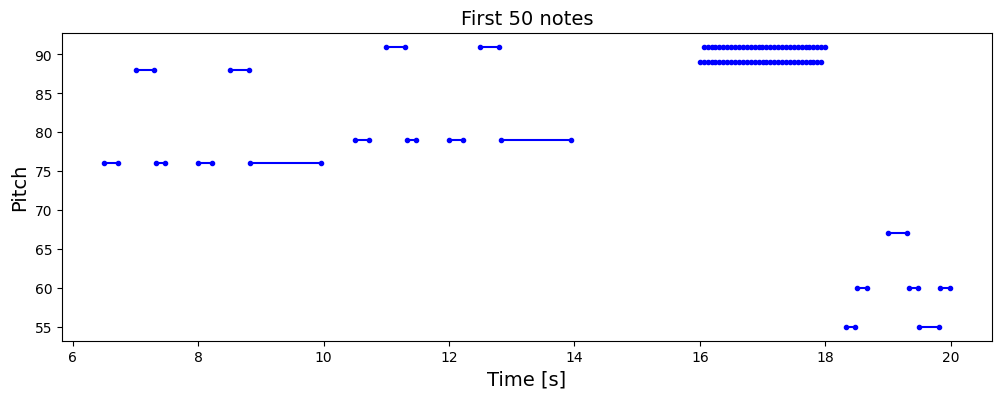

In [54]:
instrument_pm = pm.instruments[2]
plot_piano_roll(midi_to_notes(instrument_pm), count=50)

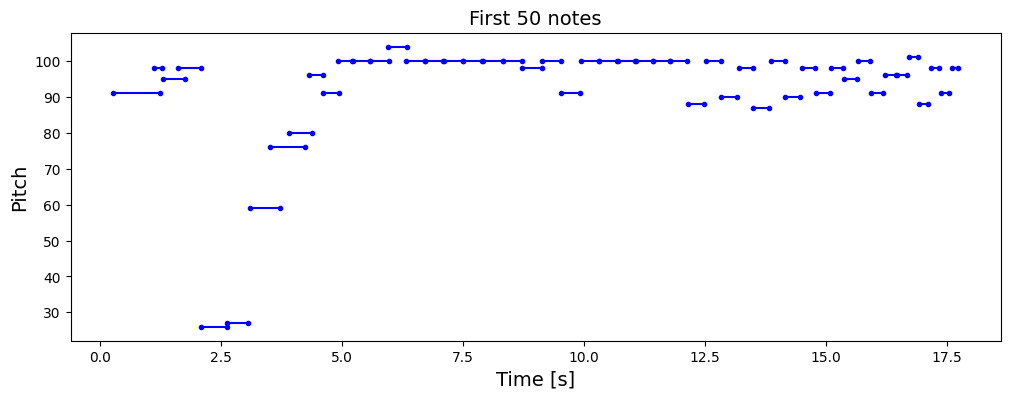

In [51]:
instrument_out = pm_together.instruments[1]
plot_piano_roll(midi_to_notes(instrument_out), count=50)

In [57]:
print(pm_together.instruments[0])

Instrument(program=32, is_drum=True, name="")
